# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2025**


----

# Trabajo práctico entregable - parte 2


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [17]:
import matplotlib.pyplot as plt
import numpy
import pandas as pd

import seaborn
seaborn.set_context('talk')

In [18]:
# Acá deberían leer el conjunto de datos que ya tienen.
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Aplicar una codificación One-hot encoding a cada fila, para las variables categóricas. Si lo consideran necesario, pueden volver a reducir el número de categorías únicas.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


# Respuesta - Ejercicio 1

In [19]:
from sklearn.feature_extraction import DictVectorizer

# Copia del dataframe sin las columnas que vamos a imputar luego
new_df = melb_df.drop(columns=['BuildingArea', 'YearBuilt'])
feature_cols = ['Suburb', 'Address', 'Rooms', 'Type', 'Price',
                'Method', 'SellerG', 'Distance', 'Bedroom2', 'Bathroom', 'Car',
                'Landsize', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']

categorical_cols = ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'CouncilArea', 'Regionname']

clean_df = new_df.copy()

# Limitar a las 5 categorías más frecuentes y reemplazar el resto por "Other"
# Pongo mayúscula a la primer letra y "_" a los espacios vacíos
for col in categorical_cols:
    clean_df[col] = clean_df[col].astype(str).str.title().str.replace(' ', '_')
    top_5 = clean_df[col].value_counts().nlargest(5).index
    clean_df[col] = clean_df[col].where(clean_df[col].isin(top_5), 'Other')

# Crear lista de diccionarios para DictVectorizer
feature_dict = list(clean_df[feature_cols].T.to_dict().values())

# Aplicar DictVectorizer
vec = DictVectorizer()
feature_matrix = vec.fit_transform(feature_dict)

if numpy.any(numpy.isnan(feature_matrix.data)):
    feature_matrix.data = numpy.nan_to_num(feature_matrix.data)


## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer` para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [20]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

# Respuesta - Ejercicio 2

Con respecto al punto 2.2: **Es necesario** escalar los datos previamente de usar `IterativeImputer`, algunas variables como `Landsize` o `BuildingArea` tendrán valores más grandes por su medición, mientras que otras como `Rooms` o `Car` valores muy pequeños. No escalar antes puede alterar el resultado.

Utilizo `MinMaxScaler` también usado en el teórico.

In [21]:
import numpy as np

# Extraigo YearBuilt y Buil
cols_to_impute = melb_df[['YearBuilt', 'BuildingArea']].values

# Concatenar al final de la feature_matrix
from scipy import sparse
X_full = sparse.hstack([feature_matrix, cols_to_impute], format='csr')

In [22]:
# 2.1)

import numpy as np

# Extraigo YearBuilt y BuildingArea
cols_to_impute = melb_df[['YearBuilt', 'BuildingArea']].values

# Concatenar al final de la feature_matrix
from scipy import sparse
concat_matrix = sparse.hstack([feature_matrix, cols_to_impute], format='csr')

# 2.2)

from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

# Escalamos los datos
dense = concat_matrix.toarray()
scaler = MinMaxScaler()
scaled = scaler.fit_transform(dense)

# Aplicar imputación
imputer = IterativeImputer(estimator=KNeighborsRegressor(n_neighbors=5), max_iter=20, random_state=0)
imputed = imputer.fit_transform(scaled)

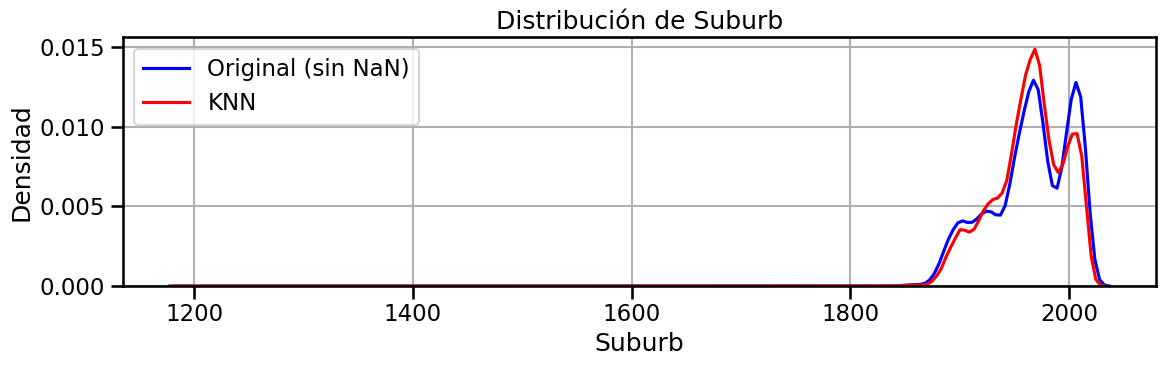

In [23]:
# 2.3)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# Recuperamos los valores originales
original = melb_df[['YearBuilt', 'BuildingArea']].copy()

simple_imputer = SimpleImputer(strategy='mean')
mean_imputed = simple_imputer.fit_transform(original)

imputed_inverse = scaler.inverse_transform(imputed)
imputed_knn = imputed_inverse[:, -2:]

def plot_distributions(variable_index, name):
    plt.figure(figsize=(12, 4))

    sns.kdeplot(original.iloc[:, variable_index].dropna(), label='Original (sin NaN)', color='blue')
    sns.kdeplot(imputed_knn[:, variable_index], label='KNN', color='red')

    plt.title(f'Distribución de {name}')
    plt.legend()
    plt.xlabel(name)
    plt.ylabel('Densidad')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_distributions(0, 'Suburb')

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos?
2. Seleccione las primeras $2$ columnas de la matriz transformada para agregar como nuevas características al conjunto de datos. Realizar un gráfico de la componente principal 1 vs la componente principal 2 (pca1-pca2).
3. Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

**Ejemplo de código para este problema**

In [24]:
## Utilizo el código de ejemplo
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

## Supongamos solo estas variables
categorical_cols = ['Type', 'Regionname']
numerical_cols = ['Rooms', 'Distance']
new_columns = []

# Paso 1: codificamos las variables categóricas
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(melb_df[categorical_cols])
for col, col_values in zip(categorical_cols, encoder.categories_):
  for col_value in col_values:
    new_columns.append('{}={}'.format(col, col_value))
print("Matrix has shape {}, with columns: {}".format(X_cat.shape, new_columns))

# Paso 2: anexamos las variables numéricas
X = numpy.hstack([X_cat, melb_df[numerical_cols].values])
new_columns.extend(numerical_cols)
print("Matrix has shape {}, with columns: {}".format(X_cat.shape, new_columns))

# Paso 3: usamos las dos primeras componentes principales a nuestro conjunto de datos
pca = PCA(n_components=2)
pca_dummy_features = pca.fit_transform(X)
X_pca = numpy.hstack([X, pca_dummy_features])
new_columns.extend(['pca1', 'pca2'])

## Paso 4: rearmamos el datagframe (ver que al final tenemos las componentes principales)
processed_melb_df = pd.DataFrame(data=X_pca, columns=new_columns)
processed_melb_df.head()

## Falta la parte de guardarlo en un archivo

Matrix has shape (13580, 11), with columns: ['Type=h', 'Type=t', 'Type=u', 'Regionname=Eastern Metropolitan', 'Regionname=Eastern Victoria', 'Regionname=Northern Metropolitan', 'Regionname=Northern Victoria', 'Regionname=South-Eastern Metropolitan', 'Regionname=Southern Metropolitan', 'Regionname=Western Metropolitan', 'Regionname=Western Victoria']
Matrix has shape (13580, 11), with columns: ['Type=h', 'Type=t', 'Type=u', 'Regionname=Eastern Metropolitan', 'Regionname=Eastern Victoria', 'Regionname=Northern Metropolitan', 'Regionname=Northern Victoria', 'Regionname=South-Eastern Metropolitan', 'Regionname=Southern Metropolitan', 'Regionname=Western Metropolitan', 'Regionname=Western Victoria', 'Rooms', 'Distance']


,Type=h,Type=t,Type=u,Regionname=Eastern Metropolitan,Regionname=Eastern Victoria,Regionname=Northern Metropolitan,Regionname=Northern Victoria,Regionname=South-Eastern Metropolitan,Regionname=Southern Metropolitan,Regionname=Western Metropolitan,Regionname=Western Victoria,Rooms,Distance,pca1,pca2
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.5,-7.669418,-0.292703
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.5,-7.669418,-0.292703
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,2.5,-7.620201,0.619633
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,2.5,-7.620201,0.619633
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,2.5,-7.570984,1.531969


# Respuesta - Ejercicio 3

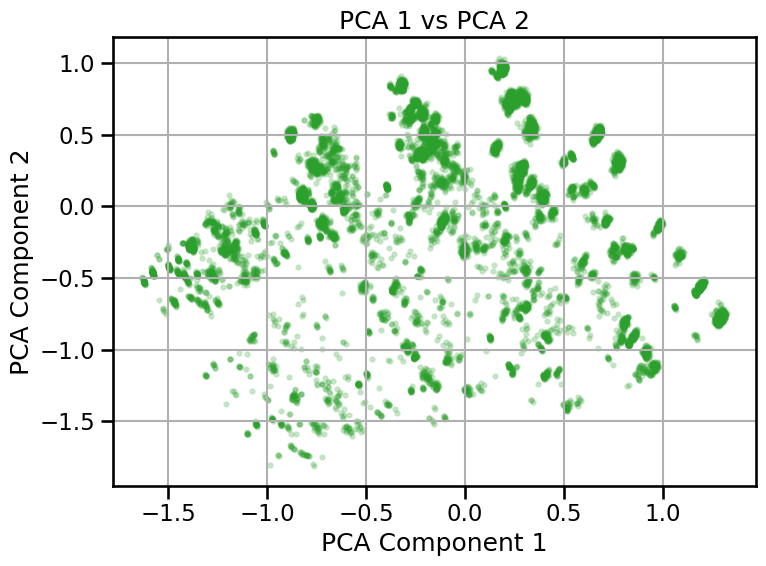

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 3.1)
n_components = min(20, imputed.shape[0])
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(imputed)

# 3.2)
pca1 = pca_result[:, 0]
pca2 = pca_result[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(pca1, pca2, alpha=0.2, s=10, c='tab:green')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA 1 vs PCA 2')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3.3)
vec_feature_names = vec.get_feature_names_out()
original_col_count = len(vec_feature_names)

# Columnas finales: nombres del vectorizador + YearBuilt + BuildingArea + pca1 + pca2
final_columns = list(vec_feature_names) + ['YearBuilt', 'BuildingArea', 'pca1', 'pca2']

# Construimos la matriz final
final_data = np.hstack([imputed, pca_result[:, :2]])

# Creo y guardo el df
processed_melb_df = pd.DataFrame(final_data, columns=final_columns)
processed_melb_df.to_csv('melb_processed_pca.csv', index=False)

## Ejercicio 4: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas y de imputación de datos faltantes
  2. Interpretación de las columnas presentes
  3. Todas las transofrmaciones realizadas
  4. Análisis breve de lo observado mediante PCA.

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
